In [17]:
using ITensorMPS
using ITensors
using Plots
using DelimitedFiles
using ITensorEntropyTools
using Combinatorics

# Find Ground State

In [2]:
N_s = 16
sites = siteinds("S=1/2", N_s)

J = 1.0
h = 1
g = 0.05


os = OpSum()
for j=1:N_s
    if j == N_s
        os -= J, "X", j, "X", 1
        os -= g, "Z", j, "Z", 1
    else
        os -= J, "X", j, "X", j+1
        # os -= g, "Z", j, "Z", j+1
    end
    os -= h, "Z", j
end
H = MPO(os, sites)

psi0 = randomMPS(sites; linkdims=2^7)

nsweeps = 15
maxdim = [10,20,100,100,200]
cutoff = [1E-10]
noise = [1E-6]
weight = 50

energy0,psi0 = dmrg(H,psi0;nsweeps,maxdim,cutoff)

After sweep 1 energy=-20.40545867474602  maxlinkdim=10 maxerr=5.70E-03 time=7.653
After sweep 2 energy=-20.429577831142986  maxlinkdim=20 maxerr=4.35E-08 time=0.013
After sweep 3 energy=-20.432393440089566  maxlinkdim=36 maxerr=9.95E-11 time=0.035
After sweep 4 energy=-20.432438011402883  maxlinkdim=34 maxerr=9.89E-11 time=0.030
After sweep 5 energy=-20.432438208412673  maxlinkdim=29 maxerr=9.91E-11 time=0.025
After sweep 6 energy=-20.432438208206417  maxlinkdim=29 maxerr=9.65E-11 time=0.025
After sweep 7 energy=-20.43243820821016  maxlinkdim=29 maxerr=9.49E-11 time=0.025
After sweep 8 energy=-20.432438208210254  maxlinkdim=29 maxerr=9.49E-11 time=0.024
After sweep 9 energy=-20.43243820821026  maxlinkdim=29 maxerr=9.49E-11 time=0.025
After sweep 10 energy=-20.432438208210197  maxlinkdim=29 maxerr=9.49E-11 time=0.024
After sweep 11 energy=-20.432438208210257  maxlinkdim=29 maxerr=9.49E-11 time=0.027
After sweep 12 energy=-20.432438208210215  maxlinkdim=29 maxerr=9.49E-11 time=0.028
Afte

(-20.432438208210243, MPS(16))

# Two-Particle Scattering

In [3]:
function rz(theta::Float64, i::Int, psi::MPS, cutoff::Float64)
    s = siteinds(psi)
    z_i = op("Z", s[i])
    Op = exp(-1im/2 * theta * z_i)
    psi = apply(Op, psi; cutoff)
    return psi
end

function giv_op(theta::Float64, i::Int, j::Int, psi::MPS, cutoff::Float64)
    s = siteinds(psi)
    x_i = op("X", s[i])
    y_i = op("Y", s[i])
    x_j = op("X", s[j])
    y_j = op("Y", s[j])
    Op = x_i * y_j - x_j * y_i
    Op = exp(1im * theta / 2 * Op)
    psi = apply(Op, psi; cutoff)
    return psi
end

giv_op (generic function with 1 method)

In [4]:
betas_r = [-2.15984495, -0.78539816,  0.58904862,  1.96349541, -2.94524311,
       -1.57079633, -0.19634954,  1.17809725]
thetas_r = [-0.04452199, -0.10805302, -0.25917978, -0.58569283, -1.0800755 ,
       -1.4472062 , -1.55743797]

betas_l = [-2.55254403,  2.35619449,  0.9817477 , -0.39269908, -1.76714587,
       -3.14159265,  1.76714587,  0.39269908]
thetas_l = [-0.04452199, -0.10805302, -0.25917978, -0.58569283, -1.0800755 ,
       -1.4472062 , -1.55743797]

7-element Vector{Float64}:
 -0.04452199
 -0.10805302
 -0.25917978
 -0.58569283
 -1.0800755
 -1.4472062
 -1.55743797

In [5]:
cutoff = 1E-8

# Make an array of 'site' indices
s = siteinds(psi0)

# State Preparation
vacs = ["0" for n = 1:N_s]
vac = MPS(s, vacs)
n_kr = 7
n_kl = -n_kr
r   = [-Int(N_s/4) + i for i=1:Int(N_s/2)]
width_wp = length(r)
xr0 = 4
xl0 = 12
sigma = 3/2


init_state = deepcopy(psi0)

for x in 1:Int(N_s/2)
    init_state = rz(betas_r[x], x, init_state, cutoff)
end
for x in 1:Int(N_s/2-1)
    y = Int(N_s/2) - x
    init_state = giv_op(thetas_r[x], y, y+1, init_state, cutoff)
end
sm = op("X", s[1]) - 1im * op("Y", s[1])
init_state = apply(sm, init_state; cutoff)
for x in 1:Int(N_s/2-1)
    y = Int(N_s/2) - x
    init_state = giv_op(-thetas_r[y], x, x+1, init_state, cutoff)
end
for x in 1:Int(N_s/2)
    init_state = rz(-betas_r[x], x, init_state, cutoff)
end



for x in 1:Int(N_s/2)
    init_state = rz(betas_l[x], x+Int(N_s/2), init_state, cutoff)
end
for x in 1:Int(N_s/2-1)
    y = N_s - x
    init_state = giv_op(thetas_l[x], y, y+1, init_state, cutoff)
end
for i in 1:Int(N_s/2)
    z = op("Z", s[i])
    init_state = apply(z, init_state; cutoff)
end
sm = op("X", s[Int(N_s/2+1)]) - 1im * op("Y", s[Int(N_s/2+1)])
init_state = apply(sm, init_state; cutoff)
for x in 1:Int(N_s/2-1)
    y = Int(N_s/2) - x
    init_state = giv_op(-thetas_l[y], x+Int(N_s/2), x+Int(N_s/2)+1, init_state, cutoff)
end
for x in 1:Int(N_s/2)
    init_state = rz(-betas_l[x], x+Int(N_s/2), init_state, cutoff)
end

[0.17461092712691006, 0.18780073226809174, 0.34376475266237205, 0.5854688025028442, 0.3445404792487344, 0.19104797348669433, 0.1804120247266408, 0.17996765729844305, 0.18045145223089293, 0.19113796055461324, 0.3447970018151128, 0.5857229793752811, 0.3444096163480751, 0.1897503517708496, 0.17720565294047558, 0.17414395760813034]


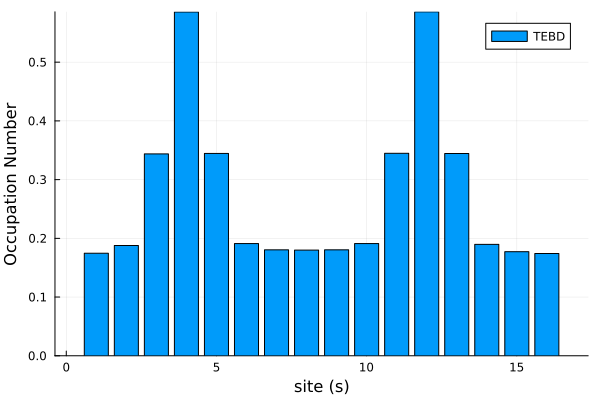

In [6]:
magz = expect(init_state, "Z")
occs = [(1 - magz[n])/2 for n=1:N_s]
println(occs)

sites = [n for n=1:N_s]
plot(bar(sites, occs; label="TEBD"), xlabel="site (s)", ylabel="Occupation Number")

# Interacting Initial State

In [7]:
# Make Time-Evolution Gates
g = 0.1
N_t = 100
tau = g / N_t

for i in 1:N_t
    for j in 1:N_s
        s1 = s[j]
        if j == N_s
            s2 = s[1]
        else
            s2 = s[j+1]
        end
        
        x1 = op("X", s1)
        x2 = op("X", s2)

        hxx = -J * x1 * x2

        Gj = exp(-1im * tau * hxx)

        init_state = apply(Gj, init_state; cutoff)

        hz = -h * op("Z", s1)
        Gj = exp(-1im * tau * hz)
        init_state = apply(Gj, init_state; cutoff)

        z1 = op("Z", s1)
        z2 = op("Z", s2)

        hzz = -tau * i * z1 * z2
        Gj = exp(-1im * tau * hzz)
        init_state = apply(Gj, init_state; cutoff)
    end
end
for i in 1:N_t
    for j in 1:N_s
        s1 = s[j]
        if j == N_s
            s2 = s[1]
        else
            s2 = s[j+1]
        end
        
        x1 = op("X", s1)
        x2 = op("X", s2)

        hxx = -J * x1 * x2

        Gj = exp(1im * tau * hxx)

        init_state = apply(Gj, init_state; cutoff)

        hz = -h * op("Z", s1)
        Gj = exp(1im * tau * hz)
        init_state = apply(Gj, init_state; cutoff)

        z1 = op("Z", s1)
        z2 = op("Z", s2)

        hzz = -g * z1 * z2
        Gj = exp(1im * tau * hzz)
        init_state = apply(Gj, init_state; cutoff)
    end
end

[0.17433942052148677, 0.18786540591374834, 0.34383726386833413, 0.5854998754672498, 0.3446414523576262, 0.19113430841530266, 0.18039470463281237, 0.17991388034979322, 0.18043186826630125, 0.19121632913349756, 0.34489449719885545, 0.5857577503293931, 0.34449105771230587, 0.18982190740239963, 0.17717539979588448, 0.17399233224015365]


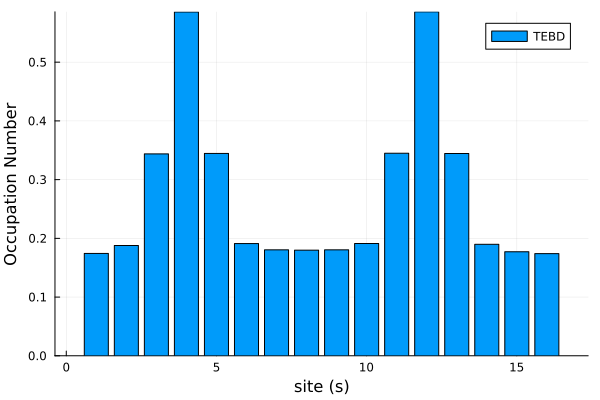

In [8]:
magz = expect(init_state, "Z")
occs = [(1 - magz[n])/2 for n=1:N_s]
println(occs)

sites = [n for n=1:N_s]
plot(bar(sites, occs; label="TEBD"), xlabel="site (s)", ylabel="Occupation Number")

# Time Evolution

In [9]:
# Make Time-Evolution Circuit
tau = 0.05
N_t = 120

gates = ITensor[]
for j in 1:N_s
    s1 = s[j]
    if j == N_s
        s2 = s[1]
    else
        s2 = s[j+1]
    end
    
    x1 = op("X", s1)
    x2 = op("X", s2)

    hxx = - J * x1 * x2

    Gj = exp(-1im * tau * hxx/2)

    push!(gates, Gj)

    hz = - h * op("Z", s1)
    Gj = exp(-1im * tau * hz/2)
    push!(gates, Gj)

    z1 = op("Z", s1)
    z2 = op("Z", s2)

    hzz = -g * z1 * z2

    Gj = exp(1im * tau * hzz/2)
    push!(gates, Gj)
end

# Include gates in reverse order too
# (N,N-1),(N-1,N-2),...
append!(gates, reverse(gates))

96-element Vector{ITensor}:
 ITensor ord=4
Dim 1: (dim=2|id=414|"S=1/2,Site,n=1")
Dim 2: (dim=2|id=676|"S=1/2,Site,n=2")
Dim 3: (dim=2|id=414|"S=1/2,Site,n=1")'
Dim 4: (dim=2|id=676|"S=1/2,Site,n=2")'
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2×2×2
[:, :, 1, 1] =
 0.9996875162757026 + 0.0im  0.0 + 0.0im
                0.0 + 0.0im  0.0 + 0.024997395914712332im

[:, :, 2, 1] =
                0.0 + 0.0im  0.0 + 0.024997395914712332im
 0.9996875162757026 + 0.0im  0.0 + 0.0im

[:, :, 1, 2] =
 0.0 + 0.0im                  0.9996875162757026 + 0.0im
 0.0 + 0.02499739591471233im                 0.0 + 0.0im

[:, :, 2, 2] =
 0.0 + 0.02499739591471233im                 0.0 + 0.0im
 0.0 + 0.0im                  0.9996875162757026 + 0.0im

 ITensor ord=2
Dim 1: (dim=2|id=414|"S=1/2,Site,n=1")'
Dim 2: (dim=2|id=414|"S=1/2,Site,n=1")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2
 0.9996875162757026 + 0.024997395914712332im  …                -0.0 + 0.0im
               -0.0 + 0.0im  

In [18]:
function entropy_von_neumann(psi::MPS)
  N = length(psi)
  s = siteinds(psi)
  entropies = []
  for b in 2:N-1
    orthogonalize!(psi, b)
    _,S = svd(psi[b], (siteind(psi, b), linkind(psi, b)))
    SvN = 0.0
    for n in 1:dim(S, 1)
      p = S[n,n]^2
      SvN -= p * log(p)
    end
    push!(entropies, SvN)
  end
  return entropies
end

function nl_magic(psi::MPS)
    N = length(psi)
    s = siteinds(psi)
    mags = []
    for b in 2:N-1
        # Assuming MPS 'psi' and bond 'b'
        orthogonalize!(psi, b)
        U, S, V = svd(psi[b], (siteind(psi,b), linkind(psi, b)))
        
        # println(size(S))
        # S contains the Schmidt coefficients (singular values)
        arg = 0.0
        for i in combinations(1:size(S, 1), 4)
            # println(i)
            l1 = S[i[1], i[1]]
            l2 = S[i[2], i[2]]
            l3 = S[i[3], i[3]]
            l4 = S[i[4], i[4]]

            i5 = mod(i[3] + i[2] + i[1], 2) + 1
            l5 = S[i[i5], i[i5]]

            i6 = mod(i[4] + i[2] + i[1], 2) + 1
            # println(i6)
            l6 = S[i[i6], i[i6]]

            i7 = mod(i[2] + i[3] + i[4], 2) + 1
            l7 = S[i[i7], i[i7]]

            i8 = mod(i[1] + i[3] + i[4], 2) + 1
            l8 = S[i[i8], i[i8]]

            arg += l1 * l2 * l3 * l4 * l5 * l6 * l7 * l8
        end
        mag = -log(arg)
        push!(mags, mag)
    end
    return mags
end

# Compute and print <Sz> at each time step
# then apply the gates to go to the next time
maxdim = 64
occs = []
EEs = []
nl_mags = []
dims = []
ttotal = N_t * tau
state = deepcopy(init_state)
for t in 0:tau:ttotal
    # println("Pass 1")
    Sz = expect(state, "Z")
    occ = [(1 - Sz[n])/2 for n=1:N_s]
    push!(occs, occ)

    EE = entropy_von_neumann(state)
    push!(EEs, EE)

    nl_mag = nl_magic(state)
    push!(nl_mags, nl_mag)
    
    bond_dim = maxlinkdim(state)
    push!(dims, bond_dim)
    t ≈ ttotal && break

    state = apply(gates, state; cutoff, maxdim)
    normalize!(state)
end

In [19]:
# sites = [n for n=1:N_s]
# for p in 1:length(occs)
#     if (p - 1) % 10 == 0
#         plt = plot(bar(sites, occs[p]; label="TEBD"); ylims= (0,0.6), xlabel="site")
#         png(plt, "Plots/plt" * string(p) * ".png")
#     end
# end

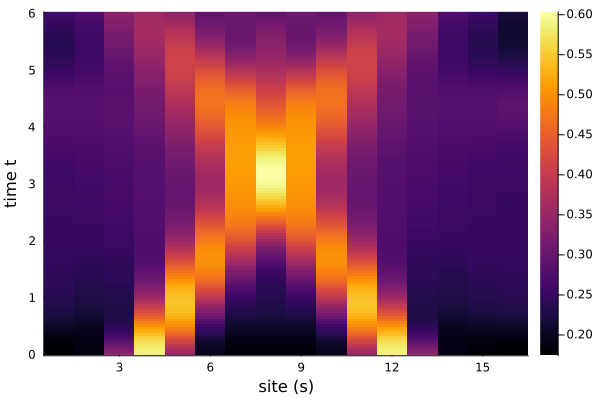

In [20]:
plot_times = zeros((N_t+1))
plot_occs = zeros((N_t+1, N_s))
for i in 1:N_t+1
    plot_times[i] = (i - 1) * tau
    for j in 1:N_s
        plot_occs[i,j] = occs[i][j]
    end
end

plot_sites = zeros((N_s))
for i in 1:N_s
    plot_sites[i] = i
end

heatmap(plot_sites, plot_times, plot_occs, xlabel="site (s)", ylabel="time t")

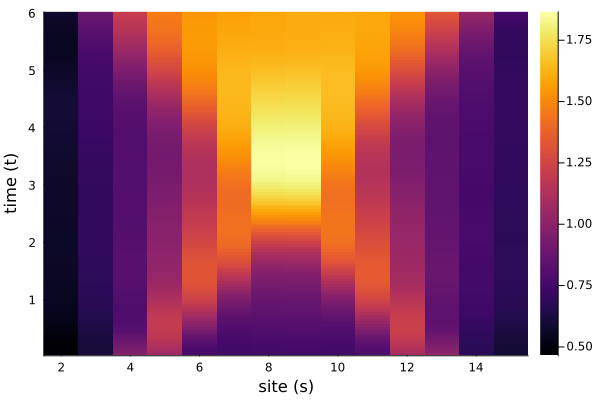

In [22]:
EEs_mat = stack(EEs, dims=1)
heatmap(2:N_s-1, tau:tau:(N_t*tau), EEs_mat[2:end,:], xlabel="site (s)", ylabel="time (t)")

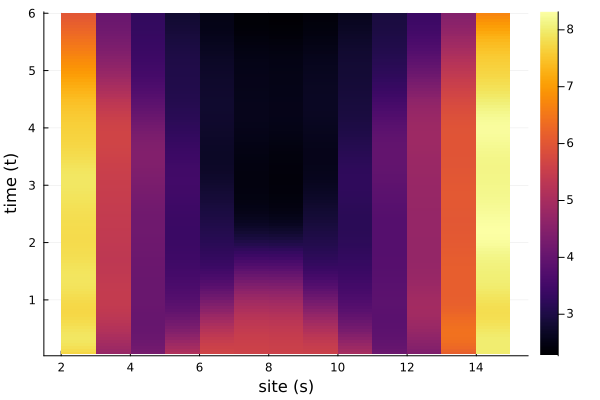

In [23]:
nl_mags_mat = stack(nl_mags, dims=1)
heatmap(2:N_s-1, tau:tau:(N_t*tau), nl_mags_mat[2:N_t,2:end], xlabel="site (s)", ylabel="time (t)")

In [24]:
nl_mags_mat = stack(nl_mags, dims=1)

121×14 Matrix{Any}:
 Inf  -2.2998   -5.24982  -5.64091  -4.75749  …  -5.61053  -3.88293  -1.94667
 Inf   7.71867   4.74396   4.25333   5.10676      4.37594   6.14244   7.99653
 Inf   7.78413   4.79745   4.2086    5.02532      4.42162   6.21844   8.00006
 Inf   7.83778   4.85125   4.1674    4.93968      4.46737   6.28479   8.00409
 Inf   7.87875   4.90454   4.13061   4.84527      4.51274   6.33924   8.00665
 Inf   7.90577   4.95665   4.09897   4.74955  …   4.5576    6.38005   8.00551
 Inf   7.9178    5.00708   4.07305   4.6554       4.60173   6.40701   7.99816
 Inf   7.91487   5.05546   4.05306   4.56412      4.64492   6.42133   7.98293
 Inf   7.89874   5.10157   4.03852   4.47693      4.68691   6.42429   7.95986
 Inf   7.87287   5.14526   4.02907   4.39307      4.72727   6.41688   7.93074
  ⋮                                           ⋱                      
 Inf   6.33401   4.20351   3.31165   2.8841       3.52563   4.71765   7.22578
 Inf   6.28534   4.1753    3.30196   2.86845      3.

In [21]:
title = "Data/"
title *= "ising-approx-occs-N_s" * string(N_s)
title *= "-J" * string(J)
title *= "-h" * string(h)
title *= "-g" * string(g)
title *= "-width" * string(sigma)
title *= "-dt" * string(tau) * ".txt"
writedlm(title, plot_occs)

In [180]:
title

"Data/ising-approx-occs-N_s16-J1.0-h1-g0.05-width1.5-dt0.05.txt"

In [181]:
EEs_mat = stack(EEs, dims=1)
title = "Data/"
title *= "ising-approx-EEs-N_s" * string(N_s)
title *= "-J" * string(J)
title *= "-h" * string(h)
title *= "-g" * string(g)
title *= "-width" * string(sigma)
title *= "-dt" * string(tau) * ".txt"
writedlm(title, EEs_mat)

In [182]:
title

"Data/ising-approx-EEs-N_s16-J1.0-h1-g0.05-width1.5-dt0.05.txt"